In [1]:
from PIL import Image
from PIL.ExifTags import TAGS, GPSTAGS
import numpy as np
import pandas as pd
import time
import cv2
import random
import matplotlib.pyplot as plt
import os
import piexif
import math

class ImageMetaData(object):
    exif_data = None
    image = None

    def __init__(self, img_path):
        self.image = Image.open(img_path)
        #print(self.image._getexif())
        self.get_exif_data()
        super(ImageMetaData, self).__init__()

    def get_exif_data(self):
        """Returns a dictionary from the exif data of an PIL Image item. Also converts the GPS Tags"""
        exif_data = {}
        info = self.image._getexif()
        if info:
            for tag, value in info.items():
                decoded = TAGS.get(tag, tag)
                if decoded == "GPSInfo":
                    gps_data = {}
                    for t in value:
                        sub_decoded = GPSTAGS.get(t, t)
                        gps_data[sub_decoded] = value[t]

                    exif_data[decoded] = gps_data
                else:
                    exif_data[decoded] = value
                    
        self.exif_data = exif_data
        return exif_data

    def get_if_exist(self, data, key):
        if key in data:
            return data[key]
        return None

    def convert_to_degress(self, value):

        """Helper function to convert the GPS coordinates 
        stored in the EXIF to degress in float format"""
        d0 = value[0][0]
        d1 = value[0][1]
        d = float(d0) / float(d1)

        m0 = value[1][0]
        m1 = value[1][1]
        m = float(m0) / float(m1)

        s0 = value[2][0]
        s1 = value[2][1]
        s = float(s0) / float(s1)

        return d + (m / 60.0) + (s / 3600.0)

    def get_lat_lng(self):
        """Returns the latitude and longitude, if available, from the provided exif_data (obtained through get_exif_data above)"""
        lat = None
        lng = None
        exif_data = self.get_exif_data()
        #print(exif_data)
        if "GPSInfo" in exif_data:      
            gps_info = exif_data["GPSInfo"]
            gps_latitude = self.get_if_exist(gps_info, "GPSLatitude")
            gps_latitude_ref = self.get_if_exist(gps_info, 'GPSLatitudeRef')
            gps_longitude = self.get_if_exist(gps_info, 'GPSLongitude')
            gps_longitude_ref = self.get_if_exist(gps_info, 'GPSLongitudeRef')
            if gps_latitude and gps_latitude_ref and gps_longitude and gps_longitude_ref:
                lat = self.convert_to_degress(gps_latitude)
                if gps_latitude_ref != "N":                     
                    lat = 0 - lat
                lng = self.convert_to_degress(gps_longitude)
                if gps_longitude_ref != "E":
                    lng = 0 - lng
        return lat, lng

In [208]:
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        images.append(filename)
    return images

In [209]:
filename=load_images_from_folder("C:\\Users\\user\Documents\Mega Project\Simulation\mumbai flood/")

In [163]:
def decdeg2dms(dd):
    mnt,sec = divmod(dd*3600,60)
    deg,mnt = divmod(mnt,60)
    return deg,mnt,sec

In [7]:
folder="mumbai flood"
folder2="mumbai flood 2"
for filename in os.listdir(folder):
    try:
        img = Image.open(folder+"/"+filename)
        img=img.convert('RGB')

        dd=random.randrange(188927,193032,33)
        deglat,mntlat,seclat=decdeg2dms(dd/10000)

        dd=random.randrange(727799,730118,18)
        deglon,mntlon,seclon=decdeg2dms(dd/10000)

        gps_ifd = {piexif.GPSIFD.GPSVersionID: (2, 0, 0, 0),
                   piexif.GPSIFD.GPSLatitude: ((int(deglat), 1), (int(mntlat), 1), (int(seclat*10000),10000)),
                   piexif.GPSIFD.GPSLongitude:((int(deglon), 1), (int(mntlon), 1), (int(seclon*10000),10000)),
                   piexif.GPSIFD.GPSDateStamp: u"1999:99:99 99:99:99",
                   }

        exif_dict = {"GPS":gps_ifd}
        exif_bytes = piexif.dump(exif_dict)
        print(filename)
        img.save(folder2+"/"+filename, exif=exif_bytes)
        i=i+1
        #print(exif_dict['GPS'][piexif.GPSIFD.GPSLatitude])
    except:
        continue

mumbai flood_10.jpg
mumbai flood_100.jpg
mumbai flood_101.jpg
mumbai flood_102.jpg
mumbai flood_103.jpg
mumbai flood_104.jpg
mumbai flood_105.jpg
mumbai flood_106.jpg
mumbai flood_108.jpg
mumbai flood_109.jpg
mumbai flood_11.jpg
mumbai flood_110.jpg
mumbai flood_111.jpg
mumbai flood_112.jpg
mumbai flood_115.jpg
mumbai flood_116.jpg
mumbai flood_117.jpg
mumbai flood_118.jpg
mumbai flood_119.jpg


C:\Users\user\.conda\envs\tcs\lib\site-packages\PIL\Image.py:2685: UserWarning: image file could not be identified because WEBP support not installed
  warnings.warn(message)


mumbai flood_12.jpg
mumbai flood_120.jpg
mumbai flood_121.jpg
mumbai flood_123.jpg
mumbai flood_125.jpg
mumbai flood_126.jpg
mumbai flood_127.jpg
mumbai flood_129.jpg
mumbai flood_13.jpg
mumbai flood_130.jpg
mumbai flood_131.jpg
mumbai flood_132.jpg
mumbai flood_134.jpg
mumbai flood_135.jpg
mumbai flood_136.jpg
mumbai flood_137.jpeg
mumbai flood_138.jpg
mumbai flood_139.jpg
mumbai flood_140.jpg
mumbai flood_141.jpg
mumbai flood_142.jpg
mumbai flood_144.jpg
mumbai flood_145.jpg
mumbai flood_146.jpg
mumbai flood_147.jpg
mumbai flood_148.jpeg
mumbai flood_15.jpeg
mumbai flood_150.jpg
mumbai flood_152.jpg
mumbai flood_153.jpg
mumbai flood_154.jpg
mumbai flood_155.jpg
mumbai flood_156.jpg
mumbai flood_158.jpg
mumbai flood_16.jpg
mumbai flood_161.jpeg
mumbai flood_162.png
mumbai flood_163.jpg
mumbai flood_164.jpg
mumbai flood_165.png
mumbai flood_166.jpg
mumbai flood_167.jpg
mumbai flood_17.jpg
mumbai flood_171.jpg
mumbai flood_172.jpg
mumbai flood_173.jpg
mumbai flood_174.jpeg
mumbai flood_

mumbai flood_534.jpg
mumbai flood_536.jpg
mumbai flood_537.jpg
mumbai flood_538.jpg
mumbai flood_539.jpg
mumbai flood_540.jpg
mumbai flood_541.jpg
mumbai flood_543.jpg
mumbai flood_544.jpg
mumbai flood_545.jpg
mumbai flood_546.jpg
mumbai flood_547.jpg
mumbai flood_548.jpg
mumbai flood_549.jpg
mumbai flood_55.jpg
mumbai flood_550.jpg
mumbai flood_551.jpg
mumbai flood_552.jpg
mumbai flood_553.jpeg
mumbai flood_554.jpg
mumbai flood_555.jpg
mumbai flood_556.jpg
mumbai flood_557.jpg
mumbai flood_558.jpg
mumbai flood_56.jpg
mumbai flood_560.jpg
mumbai flood_561.jpg
mumbai flood_562.jpg
mumbai flood_563.jpg
mumbai flood_564.jpg
mumbai flood_565.jpg
mumbai flood_566.jpg
mumbai flood_567.jpg
mumbai flood_568.jpg
mumbai flood_569.jpg
mumbai flood_57.jpg
mumbai flood_570.jpg
mumbai flood_571.jpg
mumbai flood_572.jpg
mumbai flood_573.jpg
mumbai flood_574.jpg
mumbai flood_575.jpg
mumbai flood_576.jpg
mumbai flood_577.jpg
mumbai flood_578.jpg
mumbai flood_579.jpeg
mumbai flood_58.jpg
mumbai flood_58

In [228]:
#chennai 2
centerlat=[13.1187,13.0764,13.0086,12.8389,12.932294,13.001666]
centerlon=[80.2622,80.2073,80.2186,80.2165,80.182318, 80.137055]

In [ ]:
#chennai
centerlat=[13.1234,13.1187,13.0764,13.0676,13.0380,13.0086,12.9881,12.8389,12.911227,12.932294]
centerlon=[80.1767,80.2622,80.2073,80.2529,80.2655,80.2186,80.2532,80.2165,80.136081,80.182318]

In [2]:
#mumbai
centerlat=[19.2313,18.9652,19.2380,19.0058,19.1849,19.1159,19.0600,19.1166,19.1628,19.2168,19.1369]
centerlon=[72.7945,72.8219,72.8531,72.8439,72.8494,72.8510,72.8966,72.9103,72.9502,72.9790,72.8314]

In [190]:
def distance(originlat,originlon,destlat,destlon):
    from math import sin, cos, sqrt, atan2, radians
    lat=[0,0]
    lon=[0,0]
    R=6373.0
    lat[0]=radians(originlat)
    lon[0]=radians(originlon)
    lat[1]=radians(destlat)
    lon[1]=radians(destlon)
    dlon=lon[1]-lon[0]
    dlat=lat[1]-lat[0]
    a= sin(dlat/ 2)**2 + cos(lat[0]) * cos(lat[1]) * sin(dlon/ 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
  #  print(originlat,",",originlon,",",destlat,",",destlon)
    distance = R * c
    return distance

In [11]:
from math import sin, cos, sqrt, atan2, radians
destlat=0
destlon=0
index=0

for i in range(len(centerlat)):
    for j in range(46):
        try:
            img = Image.open("mumbai flood/"+filename[index])
            img=img.convert('RGB')
            while(1):
                destlat=random.randrange(188927,193032,33)
                destlon=random.randrange(727799,730118,18)
                x=distance(centerlat[i],centerlon[i],destlat/10000,destlon/10000)
                if(x<2):
                    print(x)
                    break                
            deglat,mntlat,seclat=decdeg2dms(destlat/10000)
            deglon,mntlon,seclon=decdeg2dms(destlon/10000)

            gps_ifd = {piexif.GPSIFD.GPSVersionID: (2, 0, 0, 0),
                   piexif.GPSIFD.GPSLatitude: ((int(deglat), 1), (int(mntlat), 1), (int(seclat*10000),10000)),
                   piexif.GPSIFD.GPSLongitude:((int(deglon), 1), (int(mntlon), 1), (int(seclon*10000),10000)),
                   piexif.GPSIFD.GPSDateStamp: u"1999:99:99 99:99:99",
                   }
            exif_dict = {"GPS":gps_ifd}
            exif_bytes = piexif.dump(exif_dict)
            print(filename[index])
            img.save(f"mumbai flood 3/"+filename[index], exif=exif_bytes)
            index=index+1
        except:
            index=index+1
            continue

In [68]:
import requests
import json
response=requests.get("https://maps.googleapis.com/maps/api/geocode/json?latlng=19.179830194444445,71.78717183333333&key=YOUR_API_KEY")
data = json.loads(response.text)
        

In [231]:
from math import sin, cos, sqrt, atan2, radians
destlat=0
destlon=0
index=0
val=494
no_clusters=0
cluster=[]
for i in range(len(centerlat)):
    if(i==len(centerlat)-1):
        no_clusters=val
        val=val-no_clusters
    while(val>0):
        no_clusters=random.randrange(10,150,1)
        if(10*(len(centerlat)-i-1)<val-no_clusters):
            val=val-no_clusters
            break
    cluster.append(no_clusters)
    print(no_clusters)
    x, y = np.random.multivariate_normal([centerlat[i], centerlon[i]], [[1, 0],[0, 1]],no_clusters).T
    x=(x-min(x))/(max(x)-min(x))
    y=(y-min(y))/(max(y)-min(y))
    x=centerlat[i]-0.02+0.04*x
    y=centerlon[i]-0.02+0.04*y
    for j in range(no_clusters):
        try:
            img = Image.open("chennai flood/"+filename[index])
            img=img.convert('RGB')
            deglat,mntlat,seclat=decdeg2dms(x[j])
            deglon,mntlon,seclon=decdeg2dms(y[j])

            gps_ifd = {piexif.GPSIFD.GPSVersionID: (2, 0, 0, 0),
                   piexif.GPSIFD.GPSLatitude: ((int(deglat), 1), (int(mntlat), 1), (int(seclat*10000),10000)),
                   piexif.GPSIFD.GPSLongitude:((int(deglon), 1), (int(mntlon), 1), (int(seclon*10000),10000)),
                   piexif.GPSIFD.GPSDateStamp: u"1999:99:99 99:99:99",
                   }
            exif_dict = {"GPS":gps_ifd}
            exif_bytes = piexif.dump(exif_dict)
            #print(filename[index])
            img.save(f"chennai flood 4/"+filename[index], exif=exif_bytes)
            index=index+1
        except:
            index=index+1
            continue

44
39
111
54
93
153


In [233]:
cluster

[44, 39, 111, 54, 93, 153]

In [16]:
x=min(latitude)
y=max(latitude)

In [158]:
x, y = np.random.multivariate_normal([centerlat[i], centerlon[i]], [[1, 0],[0, 1]], 1000).T

In [155]:
x=(x-min(x))/(max(x)-min(x))
y=(y-min(y))/(max(y)-min(y))

In [102]:
x+=1
y+=1

In [104]:
x=centerlat[0]-0.01+0.02*x
y=centerlon[0]-0.01+0.02*y

<function matplotlib.pyplot.show(*args, **kw)>

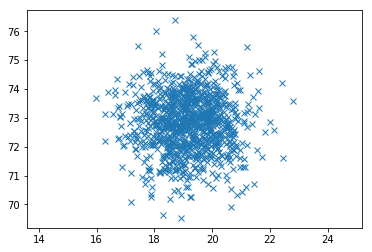

In [159]:
plt.plot(x, y, 'x')
plt.axis('equal')
plt.show

In [111]:
for i in range(len(centerlat)):
    x, y = np.random.multivariate_normal([centerlat[i], centerlon[i]], [[1, 0],[0, 1]], 46).T
    x=(x-min(x))/(max(x)-min(x))
    y=(y-min(y))/(max(y)-min(y))
    x=centerlat[0]-0.01+0.02*x
    y=centerlon[0]-0.01+0.02*y
    print(x,y)
    print("\n \n \n \n")

[19.22812423 19.23646949 19.22772345 19.23216685 19.23162108 19.23425281
 19.22661108 19.23583386 19.2337516  19.23340533 19.2309377  19.22778884
 19.23473016 19.22600072 19.22971326 19.2383429  19.23635111 19.22807822
 19.23262017 19.22637517 19.22752021 19.24065493 19.23426305 19.23084613
 19.22739116 19.23281646 19.23062108 19.23376143 19.22607737 19.22846792
 19.2213     19.23473783 19.23132397 19.22895829 19.22836943 19.23379912
 19.23169688 19.2332924  19.22974746 19.23183592 19.22792688 19.23295214
 19.22657684 19.2413     19.22514784 19.22862237] [72.78998405 72.79943783 72.79705264 72.79691598 72.8038796  72.79979837
 72.78920097 72.79855813 72.80272915 72.79942347 72.79808436 72.79934058
 72.79723846 72.80083032 72.79153994 72.7950811  72.80256321 72.79948516
 72.8045     72.79945943 72.78712354 72.7845     72.79012455 72.80215033
 72.79693272 72.79322076 72.80201079 72.8023402  72.80162279 72.78677896
 72.80097863 72.79724963 72.80088879 72.80377202 72.79436971 72.79308904
 

In [4]:
i=0
no_clusters=10
x, y = np.random.multivariate_normal([centerlat[i], centerlon[i]], [[1, 0],[0, 1]],no_clusters).T